## OBjective
To build a Covolutional Autoencoder(CAE) that compresses facial images into a lower-dimensioal latent representation and reconstructs them with minimum loss of information

## Purpose
A convolutional Autoencoder is an unsupervised deep learning model used for:

Image Compression image Reconstruction Feature Extraction Dimensionality Reduction.

The encoder learns a compressed representation(latent space),while the decoder reconstructs the original image from this compressed representation.

In [2]:
# Libraries

import os # Provides functions for interacting with the operating system, like file paths and directories.
import shutil # Offers high-level file operations, such as copying and moving files.
import numpy as np # Fundamental package for scientific computing with Python, especially for arrays.
import matplotlib.pyplot as plt # A plotting library for creating static, interactive, and animated visualizations.

import tensorflow as tf # Google's open-source machine learning framework.

from tensorflow.keras.preprocessing.image import ImageDataGenerator # Utility for real-time data augmentation on image data.
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D # Input: Defines the input shape; Conv2D: 2D Convolutional Layer for feature extraction; MaxPooling2D: Reduces spatial dimensions; UpSampling2D: Increases spatial dimensions.
from tensorflow.keras.models import Model # Used to define a Keras model.

In [3]:
#import dataset

import kagglehub

path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [4]:
#Create a smaller dataset (5000 images)
source_folder = os.path.join(path,"img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )
print("Copied",len(images),"images")

Copied 5000 images


In [5]:
#configure kaggle
# Create a .kaggle directory in the user's home directory if it doesn't exist
!mkdir -p ~/.kaggle
# Copy the kaggle.json file (which contains API credentials) to the .kaggle directory
!cp kaggle.json ~/.kaggle/
# Set appropriate permissions for the kaggle.json file (read/write for owner only) for security
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [6]:
# Data Preprocessing
# Define the target image dimensions (width, height) for resizing all input images.
IMAGE_SIZE =(64,64)
# Define the number of samples (images) to be processed in one batch during training/inference.
BATCH_SIZE =32

In [7]:
from IPython.utils.text import re # Imports the 're' module for regular expressions from IPython's utility library.
datagen=ImageDataGenerator(
    rescale=1./255, # Rescales pixel values from [0, 255] to [0, 1] for normalization.
    validation_split=0.2 # Reserves 20% of the images for validation.
)

In [8]:
# Load Dataset
train_generator=datagen.flow_from_directory(
    "celeba_small", # Specifies the directory containing the images for the generator.
    target_size=IMAGE_SIZE, # Resizes all images to the dimensions defined by IMAGE_SIZE (64x64).
    batch_size=BATCH_SIZE, # Sets the number of images to yield in each batch (32 images).
    class_mode="input", # For autoencoders, the input is also the target, so 'input' is used.
    subset="training" # Specifies that this generator should use the training subset of the data.
)

Found 4000 images belonging to 1 classes.


In [9]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


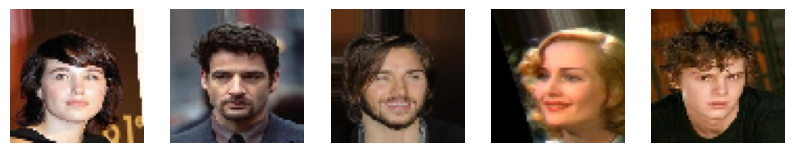

In [28]:
#Diaplay Sample Images
images,_ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [11]:
#Build Convolutional Autoencoder
#Encoder

input_img = Input(shape=(64,64,3))
x=Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)
x= MaxPooling2D(
    (2,2),
    padding='same'
)(x)
x=Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)
encoded= MaxPooling2D(
    (2,2),
    padding='same'
)(x)

In [12]:
#Decoder
from IPython.utils.py3compat import decode
x=Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(
    3,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)


In [13]:
#create model
autoencoder=Model(
    input_img,
    decoded)

In [14]:
#compile model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [15]:
#model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#Train model
history=autoencoder.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 530ms/step - loss: 0.5280 - val_loss: 0.4970
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 527ms/step - loss: 0.4939 - val_loss: 0.4929
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 529ms/step - loss: 0.4890 - val_loss: 0.4883
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 530ms/step - loss: 0.4877 - val_loss: 0.4868
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 531ms/step - loss: 0.4858 - val_loss: 0.4855
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 577ms/step - loss: 0.4853 - val_loss: 0.4857
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 586ms/step - loss: 0.4842 - val_loss: 0.4841
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 551ms/step - loss: 0.4837 - val_loss: 0.4835
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 541ms/step - loss: 0.4833 - val_loss: 0.4831
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 555ms/step - loss: 0.4833 - val_loss: 0.4826


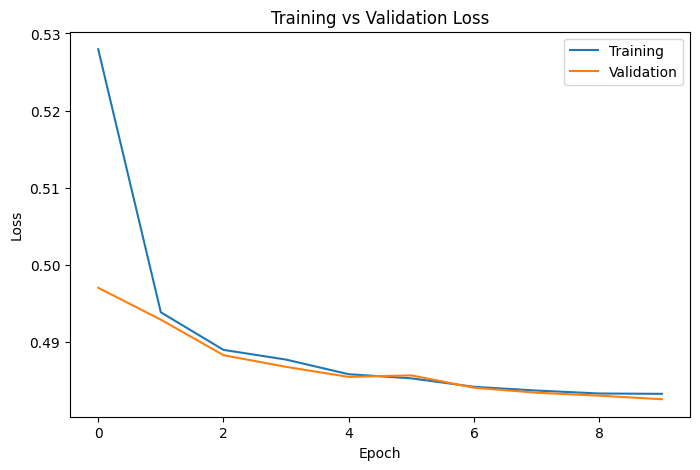

In [17]:
#plot loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend(["Training","Validation"])

plt.show()


In [18]:
#Evaluate model
loss= autoencoder.evaluate(validation_generator)

print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.4826
Validation Loss: 0.4826073944568634


In [19]:
#Reconstruct Images
images,_ = next(validation_generator)

reconstructed_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step


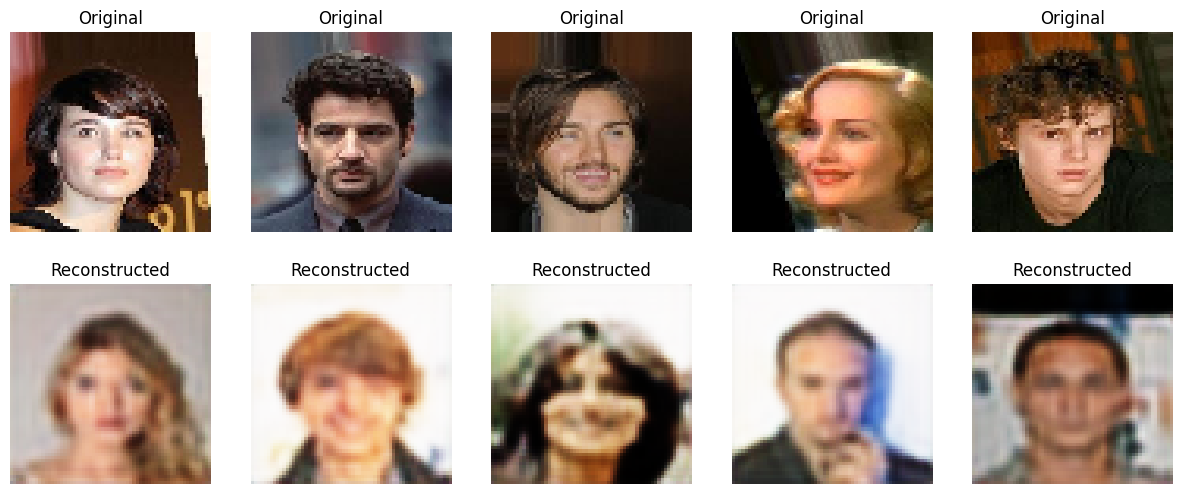

In [29]:
#Display Results
n=5

plt.figure(figsize=(15,6))

for i in range(n):

    plt.subplot(2,n,i+1)

    plt.imshow(images[i])

    plt.title("Original")

    plt.axis('off')

    plt.subplot(2,n,i+1+n)

    plt.imshow(reconstructed_images[i])

    plt.title("Reconstructed")

    plt.axis('off')

plt.show()
